In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import ztfcosmo
from scipy.stats import median_abs_deviation

In [2]:
data = ztfcosmo.get_data()

In [3]:
sn_id_file = '/home/ovive/sfm_method/data/ztf_sn_data/Ginolin25ab_masterlist.csv'
g25ab_masterlist = pd.read_csv(sn_id_file)
data_g25ab = data[(data.index.isin(g25ab_masterlist['ztfname'])) & (data['redshift'] > 0.015)].copy()

In [4]:
def get_binned_data(df, env_col, color_col='c', res_col='H_residuals', env_cut=1.0, sn_per_bin=80):
    """Given a dataframe, an environment column and an environment cut, bin the data having 80 SN per bin.

    Args:
        df (pd.DataFrame): The input dataframe containing SN data.
        env_col (str): The name of the column representing the environment.
        color_col (str, optional): The name of the column representing the color. Defaults to 'c'.
        res_col (str, optional): The name of the column representing the residuals. Defaults to 'H_residuals'.
        env_cut (float, optional): The threshold for splitting the environment column into high and low groups. Defaults to 1.0.
        sn_per_bin (int, optional): The desired number of SN per bin. Defaults to 80.

    Returns:
        dict: A dictionary containing the binned data and calculated statistics.
    """
    n_bins = len(df) // sn_per_bin + 1 # Ensure we have enough bins to accommodate all SN with the desired number per bin
    bin_edges = np.quantile(df[color_col], np.linspace(0, 1, n_bins + 1)) # Get quantile-based bin edges for the color column


    res = {'c_low': [], 'c_high': [], 'm_low': [], 'm_high': [], 'e_low': [], 'e_high': [], 'nmad_low': [], 'nmad_high': [], 'n_low': [], 'n_high': []}

    for i in range(len(bin_edges)-1):
        mask = (df[color_col] >= bin_edges[i]) & (df[color_col] < bin_edges[i+1]) # Select SN in the current color bin
        b_df = df[mask] # Subset of the dataframe for the current color bin

        # split the data by environment (h: high, l: low) using the env_cut:
        h_mask = b_df[env_col] >= env_cut
        l_mask = b_df[env_col] < env_cut

        h_df = b_df[h_mask] # Subset of the dataframe for the high environment group
        l_df = b_df[l_mask] # Subset of the dataframe for the low environment group

        # Calculate the separate x-means:
        res['c_high'].append(h_df[color_col].median()) # Use median color for the high environment group
        res['c_low'].append(l_df[color_col].median()) # Use median color for the low environment group

        # Top panel: calculate the separate H_residuals means and errors:
        h_vals = h_df[res_col].dropna() # Get the H_residuals values for the high environment group, dropping NaNs
        l_vals = l_df[res_col].dropna() # Get the H_residuals values for the low environment group, dropping NaNs

        ## Calculate means and standard errors for the H_residuals for both groups, handling cases with no data:
        res['m_high'].append(h_vals.mean()); res['m_low'].append(l_vals.mean())

        res['e_high'].append(h_vals.std()/np.sqrt(len(h_vals)) if len(h_vals) > 0 else 0)
        res['e_low'].append(l_vals.std()/np.sqrt(len(l_vals)) if len(l_vals) > 0 else 0)

        # Calculate the separate NMADs for the two groups:
        nm_h = median_abs_deviation(h_df[res_col], scale='normal') if len(h_df) > 0 else 0
        nm_l = median_abs_deviation(l_df[res_col], scale='normal') if len(l_df) > 0 else 0
        res['nmad_high'].append(nm_h)
        res['nmad_low'].append(nm_l)

        # Store the number of SN in each group for error calculations:
        res['n_high'].append(len(h_vals))
        res['n_low'].append(len(l_vals))

    for key in res.keys():
        # Convert lists to numpy arrays for easier calculations later on
        res[key] = np.array(res[key])
    # Middle panel: calculate the step and its error:
    res['step'] = np.array(res['m_low']) - np.array(res['m_high'])
    res['step_err'] = np.sqrt(np.array(res['e_high'])**2 + np.array(res['e_low'])**2)

    # Bottom panel: calculate the NMAD errors using the formula for the standard error of the median absolute deviation:
    # NMAD errors: NMAD / sqrt(2*(N-1))
    res['nmad_err_high'] = np.array(res['nmad_high']) / np.sqrt(2 * (np.array(res['n_high']) - 1))
    res['nmad_err_low'] = np.array(res['nmad_low']) / np.sqrt(2 * (np.array(res['n_low']) - 1))
    return res


def affine_func(x, m, b): return m * x + b


def plot_environmental_steps(df, env_col_local, env_col_global, env_type, 
                            gamma_val, gamma_err, color_col='c', res_col='H_residuals'):
    """_summary_

    Args:
        df (pd.DataFrame): The input dataframe containing SN data.
        env_col_local (str): The name of the column representing the local environment.
        env_col_global (str): The name of the column representing the global environment.
        env_type (str): The type of environment to analyze ('color' or 'mass').
        gamma_val (float): The value of the step.
        gamma_err (float): The error on the step.
        color_col (str, optional): The name of the column representing the color. Defaults to 'c'.
        res_col (str, optional): The name of the column representing the residuals. Defaults to 'H_residuals'.

    Raises:
        ValueError: If env_type is not 'color' or 'mass'.

    Returns:
        None
    """

    # Define settings based on type
    if env_type.lower() == 'color': # .lower() to make it case-insensitive
        env_cut = 1.0
        #primary_col = env_col_local
        env_label = r'(g-z)'
        cut_suffix = 'local'
    elif env_type.lower() == 'mass':
        env_cut = 10.0
        #primary_col = env_col_global
        env_label = r'$\log(M_*/M_\odot)$'
        cut_suffix = 'global'
    else:
        raise ValueError("env_type must be 'color' or 'mass'")

    # 1. Process data
    # Note: Using env_col local for color, global for mass to define the groups
    data_local = get_binned_data(df, env_col_local, env_cut=env_cut, color_col=color_col, res_col=res_col)
    data_global = get_binned_data(df, env_col_global, env_cut=env_cut, color_col=color_col, res_col=res_col)

    # 2. Setup Figure
    fig, (ax1, ax2, ax3) = plt.subplots(
        nrows=3, ncols=1, figsize=(6.35, 5.9),
        sharex=True, gridspec_kw={'height_ratios': [4.3, 2.8, 1.4]}
    )
    plt.subplots_adjust(hspace=0.1)

    ################################## Top Subplot: Hubble Residuals ###################################

    # c_low and c_high are the median color values for the low and high environment groups in each bin, respectively.
    # m_low and m_high are the mean Hubble residuals for the low and high environment groups in each bin, respectively.
    # e_low and e_high are the standard errors of the mean Hubble residuals for the low and high environment groups in each bin, respectively.

    ax1.errorbar(data_local['c_low'], data_local['m_low'], yerr=data_local['e_low'],
                fmt='o', color='tab:blue',
                label=f'{env_label}$_{{{cut_suffix}}} < {env_cut}$', markersize=5)
    ax1.errorbar(data_local['c_high'], data_local['m_high'], yerr=data_local['e_high'],
                fmt='o', color='tab:red',
                label=f'{env_label}$_{{{cut_suffix}}} > {env_cut}$', markersize=5)

    ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax1.set_ylabel(r'$\mu - \mu_{cosmo} - \beta c + \alpha x_1$')
    ax1.set_ylim(-0.2, 0.3)
    ax1.set_xlim(-0.15, 0.5)
    ax1.legend(loc='upper right', fontsize=8)

    ################################### Middle Subplot: Step ###################################
    # Band with the step value and its error in the paper for the full sample:
    band = ax2.axhspan(gamma_val - gamma_err, gamma_val + gamma_err,
                    color='cadetblue', alpha=0.3, zorder=0, label='Step in ' + env_label + f'$_{{{cut_suffix}}}$ for full sample')

    # c_low and c_high are the median color values for the low and high environment groups in each bin, respectively.
    # step is the difference in mean Hubble residuals between the low and high environment groups
    # step_err is the error on the step, calculated as the quadrature sum of the standard errors of the mean Hubble residuals for the low and high environment groups.

    p1 = ax2.errorbar(data_local['c_low'], data_local['step'], yerr=data_local['step_err'],
                    fmt='o', color='white', markeredgecolor='darkcyan', ecolor='darkcyan',
                    label=f'Step in {env_label}$_{{local}}$', markersize=5)

    p2 = ax2.errorbar(data_global['c_low'], data_global['step'], yerr=data_global['step_err'],
                    fmt='o', color='darkcyan', label=f'Step in {env_label}$_{{global}}$', markersize=5)

    # Add a horizontal line at y=0 for reference
    ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax2.set_ylabel('Step')
    ax2.set_ylim(-0.05, 0.5)
    ax2.set_yticks(np.arange(0, 0.51, 0.1))
    ax2.legend(handles=[p2, p1, band], ncol=2, loc='upper left', fontsize=8)

    #################################### Bottom Subplot: Scatter (NMAD) ###################################
    # c_low and c_high are the median color values for the low and high environment groups in each bin, respectively.
    # nmad_low and nmad_high are the NMAD values for the low and high environment groups in each bin, respectively.
    # nmad_err_low and nmad_err_high are the errors on the NMAD values for the low and high environment groups in each bin, respectively.

    ax3.errorbar(data_local['c_low'], data_local['nmad_low'], yerr=data_local['nmad_err_low'], 
                fmt='o', color='tab:blue', markersize=5)
    ax3.errorbar(data_local['c_high'], data_local['nmad_high'], yerr=data_local['nmad_err_high'], 
                fmt='o', color='tab:red', markersize=5)
    ax3.set_ylabel('Scatter')
    ax3.set_xlabel('c')
    ax3.set_ylim(0, 0.41)
    ax3.set_yticks(np.arange(0, 0.41, 0.2))

    return fig

#### Constants, used from the code, values of the paper also noted:

In [9]:
alpha = 0.164 # 0.164 in Ginolin's notebooks, 0.165 +-0.010 in Sec. 4 Ginolin a
beta = 3.127 # 3.127 in Ginolin's notebooks, 3.06 +-0.05 in Sec. 4 Ginolin a
gamma_full_gz = 0.157 # 0.154 in Ginolin's notebooks, 0.157 in Sec. 4.3 Ginolin a
gamma_err_gz = 0.024 # 0.022 in Ginolin's notebooks, 0.024 in Sec. 4.3 Ginolin a

gamma_full_mass = 0.162 # 0.154 in Ginolin's notebooks, 0.162 in Sec. 5 Ginolin a, using a linear alpha
gamma_err_mass = 0.020 # 0.022 in Ginolin's notebooks, 0.020 in Sec. 5 Ginolin a
M0 = -19.3 # Ginolin's notebooks, not in the paper

ZP = 10.50 # Ginolin's notebooks, not in the paper #! Taylor et al. 2023 ZP = 0

In [10]:
from astropy.cosmology import Planck18 as cosmo

data_g25ab["mag"] = (-2.5*np.log10(data_g25ab["x0"].values)+ZP) - M0 - cosmo.distmod(data_g25ab["redshift"]).value
# Ginolin's notebooks: data["mag"] = (-2.5*np.log10(data["x0"])+10.50) + 19.3 - Planck18.distmod(data["redshift"].values).value

data_g25ab["mag_err"] = +2.5/np.log(10) * data_g25ab["x0_err"] / data_g25ab["x0"]
# Ginolin's notebooks: data["mag_err"] = +2.5/np.log(10) * data["x0_err"] / data["x0"]

data_g25ab["H_residuals"] = data_g25ab["mag"] + alpha*data_g25ab["x1"] - beta*data_g25ab["c"]

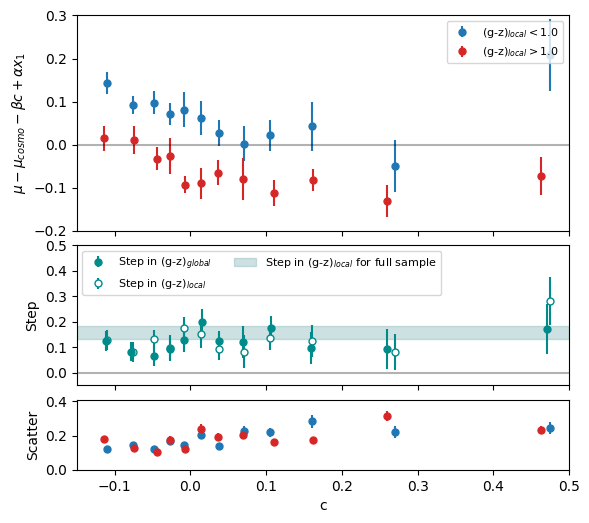

In [12]:
plot_environmental_steps(
    df=data_g25ab,
    env_col_local='localrestframe_gz',
    env_col_global='globalrestframe_gz',
    env_type='color',
    gamma_val=gamma_full_gz,
    gamma_err=gamma_err_gz
)
plt.show()

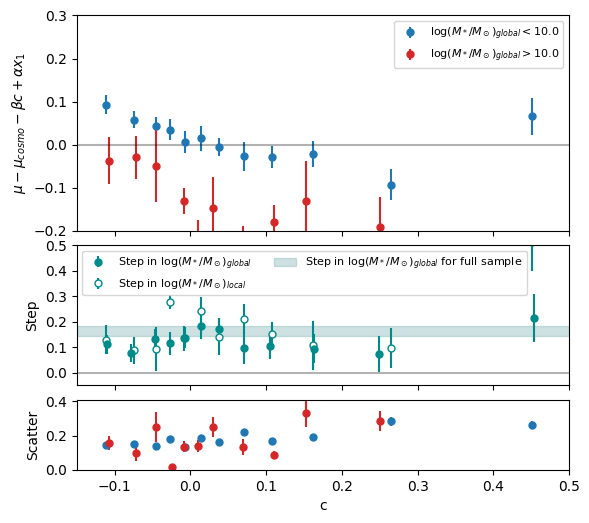

In [13]:
plot_environmental_steps(
    df=data_g25ab,
    env_col_local='localmass', 
    env_col_global='globalmass',
    env_type='mass',
    gamma_val=gamma_full_mass,
    gamma_err=gamma_err_mass
)
plt.show()